This notebook should serve as an extensible benchmark for methods predicting spatial cell counts from single cell data

## Setup

### Load Modules

In [13]:
from pathlib import Path
from typing import Callable, NamedTuple, List
from dataclasses import dataclass
from functools import reduce

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import NDArray
import pandas as pd
import seaborn as sns
import scanpy as sc
import sklearn as sk
import torch
from tqdm import tqdm
import tangram as tg
from scipy.stats import pearsonr, spearmanr
from scipy.spatial.distance import cosine
from sklearn.decomposition import non_negative_factorization
from sklearn.metrics import mean_squared_error
from disk_cache import disk_cache

### Data Utils

In [14]:
class Reconstruction_Result(NamedTuple):
    """
    A class to store the original and predicted gene counts along with methods
    to process and compute metrics based on those counts.

    Attributes:
        original_counts (pd.DataFrame): The original gene counts from the query data.
        predicted_counts (pd.DataFrame): The predicted gene counts from the gene prediction model.
    """

    original_counts: pd.DataFrame
    predicted_counts: pd.DataFrame

    @classmethod
    def from_gene_predictor(
        cls,
        adata_query: ad.AnnData,
        compidx: NDArray[np.str_],
        subidx: NDArray[np.str_],
        gene_predictor: Callable[[ad.AnnData, NDArray[np.str_], NDArray[np.str_]], np.ndarray],
    ) -> "Reconstruction_Result":
        """
        Creates a Reconstruction_Result instance from a gene prediction model.

        Args:
            adata_query: The AnnData object containing the query data (e.g., query spatial data).
            compidx: A numpy array of target genes for prediction
            subidx: A numpy array of input genes for prediction
            gene_predictor: A function that predicts gene counts
                based on the query AnnData object and the list of gene identifiers. It should return a NumPy array
                of predicted counts.

        Returns:
            Reconstruction_Result: A new instance containing the original and predicted gene counts as DataFrames.
        """
        return Reconstruction_Result( 
            pd.DataFrame(
                data=np.array(adata_query[:, compidx].X),
                columns=compidx,
                index=adata_query.obs.index
            ),
            pd.DataFrame(
                data=gene_predictor(adata_query, compidx, subidx),
                columns=compidx,
                index=adata_query.obs.index
            )
        )

    @classmethod
    def from_reconstruction_result_collection(
        cls,
        reconstruction_results: list["Reconstruction_Result"]
    ) -> "Reconstruction_Result":
        genes = reduce(lambda x, y: set.union(x, y), [set(reconstruction_result.predicted_counts.columns) for reconstruction_result in reconstruction_results])
        predicted_counts = pd.DataFrame()
        original_counts = pd.DataFrame()
        for gene in genes:
            predicted_counts[gene] = np.array([reconstruction_result.predicted_counts[gene].values for reconstruction_result in reconstruction_results if gene in reconstruction_result.predicted_counts.columns]).mean(axis=0)
            original_counts[gene] = np.array([reconstruction_result.original_counts[gene].values for reconstruction_result in reconstruction_results if gene in reconstruction_result.original_counts.columns]).mean(axis=0)
        return Reconstruction_Result(
            original_counts=original_counts,
            predicted_counts=predicted_counts
        )

    def compute_correlation(
        self,
        correlation_func: Callable[[np.ndarray, np.ndarray], float],
    ) -> float:
        """
        Computes the correlation between the original and predicted gene counts.

        Args:
            correlation_func (Callable[[np.ndarray, np.ndarray], float]): A function that computes the correlation
                between two NumPy arrays. It should return a single floating-point value representing the correlation.

        Returns:
            float: The computed correlation between the original and predicted gene counts.
        """
        return correlation_func(
            self.original_counts.values,
            self.predicted_counts.values
        )
    


def transform_correlation_func(
    correlation_func: Callable[[np.ndarray, np.ndarray], float], 
    transform: Callable[[np.ndarray], np.ndarray] = lambda x: x
) -> Callable[[np.ndarray, np.ndarray], float]:
    """
    Returns a correlation function that applies a transformation to inputs before computing correlation.
    """
    return lambda x, y: correlation_func(transform(x), transform(y))

def benchmark_gene_predictor(
    adata_query: ad.AnnData,
    benchmarking_genes: list[NDArray],
    n_compidx: int,
    gene_predictor: Callable[[ad.AnnData, NDArray[np.str_], NDArray[np.str_]], NDArray]
) -> List[Reconstruction_Result]:
    """
    Benchmarks a gene prediction model by evaluating its performance across multiple randomized gene sets.

    This function identifies shared genes between the query and reference datasets, 
    generates multiple random permutations of these genes, and evaluates the given gene predictor 
    using subsets of genes as input and output.

    Args:
        adata_query (ad.AnnData): The query AnnData object containing the spatial gene expression data.
        benchmarking_genes (list[NDArray]): The shuffled gene matrix used to benchmark
        n_compidx (int): The number of genes to use as input (compidx, target genes) in each benchmark run.
        gene_predictor (Callable[[ad.AnnData, NDArray[np.str_], NDArray[np.str_]], Reconstruction_Result]): 
            A function that predicts gene expression of a given target gene subset given a query dataset an input gene subset.

    Returns:
        List[Reconstruction_Result]: A list of Reconstruction_Result objects, each containing 
        the original and predicted gene expression values for a given permutation.
    """


    return [
        Reconstruction_Result.from_gene_predictor(adata_query, gene_arr[:n_compidx], gene_arr[n_compidx:], gene_predictor)
        for gene_arr in tqdm(benchmarking_genes)
    ]


### NMF Utils

In [15]:
def prepare_H_init(
    adata_reference: ad.AnnData,
    shared_genes: NDArray[np.str_],
    n_components: int
) -> pd.DataFrame:
    """
    Computes the initial H matrix for NMF using reference gene expression data.
    Args:
        adata_reference (ad.AnnData): Reference AnnData object.
        shared_genes (np.ndarray): Array of shared gene names.
        n_components (int): Number of NMF components.
    Returns:
        pd.DataFrame: Initial H matrix with genes as columns.
    """
    _, H_init, _ = non_negative_factorization(
        adata_reference[:, shared_genes].X.toarray(), 
        n_components=n_components
    )
    return pd.DataFrame(data=H_init, columns=shared_genes)


def predict_genes_nmf(
    adata_query: sc.AnnData, 
    H_init: pd.DataFrame,
    compidx: NDArray[np.str_],
    subidx: NDArray[np.str_],
) -> NDArray:
    """
    Predicts gene expression using NMF with a fixed H matrix.

    Args:
        adata_query: Query AnnData object.
        H_init: Precomputed H matrix from NMF.
        compidx: Array of target gene names.
        subidx: Array of input gene names.

    Returns:
        np.ndarray: Predicted expression values for compidx genes.
    """
    W, _, _ = non_negative_factorization(
        np.array(adata_query[:, subidx].X), 
        H=H_init[subidx].values,
        init="custom", 
        update_H=False,
        n_components=H_init.shape[0],
    )
    return W @ H_init[compidx].values

#### Architecture

In [16]:
def ReLU(Z: NDArray):
    return np.maximum(0, Z)

def ReLU_backward(dZ, Z):
    dZ[Z <= 0] = 0
    return dZ

@dataclass
class LinearLayer:
    W: np.ndarray
    b: np.ndarray

    def __post_init__(self):
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)
        self.input_cache = None  

    def forward(self, Z):
        self.input_cache = Z 
        return (Z @ self.W) + self.b
    
    def backward(self, dZ):
        dW = self.input_cache.T @ dZ  
        db = np.sum(dZ, axis=0, keepdims=True)  

        dZ_prev = dZ @ self.W.T 

        self.dW = dW
        self.db = db

        return dZ_prev 
    
    def __call__(self, Z):
        return self.forward(Z)

class Model:
    def __init__(self, n_input, n_latent, n_output):
        self.fc1 = LinearLayer(
            W=np.random.randn(n_input, n_latent) * \
                np.sqrt(2 / (n_input + n_latent)),
            b=np.zeros((1, n_latent))
        )
        self.fc2 = LinearLayer(
            W=np.random.randn(n_latent, n_output) * \
                np.sqrt(2 / (n_latent + n_output)),
            b=np.zeros((1, n_output))
        )

    def forward(self, Z):
        self.Z1 = self.fc1(Z)  
        self.A1 = ReLU(self.Z1)
        self.Z2 = self.fc2(self.A1) 
        return self.Z2

    def backward(self, dZ2):
        """Backpropagate gradients through the network."""
        dA1 = self.fc2.backward(dZ2)
        dZ1 = ReLU_backward(dA1, self.Z1)
        dX = self.fc1.backward(dZ1)
        return dX 

    def update_parameters(self, lr=0.01):
        """Update parameters using gradient descent."""
        self.fc1.W -= lr * self.fc1.dW
        self.fc1.b -= lr * self.fc1.db
        self.fc2.W -= lr * self.fc2.dW
        self.fc2.b -= lr * self.fc2.db

    def __call__(self, Z):
        return self.forward(Z)

    def train(
        self,
        data,
        n_epochs,
        learning_rate
    ):
        for _ in tqdm(range(n_epochs)):
            pass


#### Predictor

### Tangram Utils

In [17]:
@disk_cache(Path("data/tangram_cache"))
def predict_genes_tangram(
    adata_query: sc.AnnData,
    adata_reference: sc.AnnData,
    compidx: NDArray[np.str_], 
    subidx: NDArray[np.str_],
    *args,
    **kwargs
) -> NDArray:
    """
    Predicts gene expression using Tangram.

    Args:
        adata_query: Query AnnData object.
        adata_reference: Reference AnnData object.
        compidx: Array of target gene names.
        subidx: Array of input gene names.
        *args: arguments for tg.map_cells_to_space
        **args: keyword arguments for tg.map_cells_to_space

    Returns:
        np.ndarray: Predicted expression values for compidx genes.
    """
    markers = np.hstack([compidx, subidx])
    adata_reference = adata_reference[:, markers]
    adata_query_subidx = adata_query[:, subidx]
    tg.pp_adatas(
        adata_reference, adata_query_subidx, genes=markers.tolist()
    )
    ad_map = tg.map_cells_to_space(
        adata_sc=adata_reference,
        adata_sp=adata_query_subidx,
        *args,
        **kwargs
    )
    compidx_lower = np.array(
        [gene.lower() for gene in compidx]
    )
    ad_ge = tg.project_genes(ad_map, adata_reference)
    return np.array(ad_ge[:, compidx_lower].X)

### Load Data

{'BZE',
 'Blood vasc.',
 'Cycling/GC B cell',
 'Glial',
 'Goblet',
 'Lymphatic',
 'MZE',
 'Macrophage',
 'Paneth',
 'Plasma',
 'Rest B',
 'Stem/TA',
 'Stroma',
 'T cell',
 'TZE',
 'Tuft',
 'cDC/monocyte',
 'neurons/enteroendocrine',
 'pDC'}

In [18]:
# Query Dataset
adata_sp = sc.read(
   Path.cwd() / "data" / "inputQuery" / "gene_by_cell.csv",
).transpose()
adata_sp.obs = sc.read_h5ad(Path.cwd() / "data" / "nico_out" / "nico_celltype_annotation.h5ad").obs

# Reference Dataset
adata_sc = sc.read_h5ad(Path.cwd() / "data" / "inputRef" / "input_ref.h5ad")

sc.pp.filter_genes(adata_sp, min_counts=1)
sc.pp.filter_genes(adata_sc, min_counts=1)

shared_genes = np.array(list(set.intersection(set(adata_sp.var_names), set(adata_sc.var_names))))

adata_sc.obs["celltype"] = adata_sc.obs["cluster"]
adata_sp.obs["celltype"] = adata_sp.obs["nico_ct"]
print(f"{adata_sc=}\n{adata_sp=}")
celltype = "Stem/TA"
adata_sp = adata_sp[adata_sp.obs["celltype"] == celltype]
adata_sc = adata_sc[adata_sc.obs["celltype"] == celltype]

shared_genes = np.array(list(set.intersection(set(adata_sp.var_names), set(adata_sc.var_names))))

adata_sc=AnnData object with n_obs × n_vars = 2239 × 21197
    obs: 'cluster', 'celltype'
    var: 'n_counts'
adata_sp=AnnData object with n_obs × n_vars = 7416 × 241
    obs: 'umi_sct', 'log_umi_sct', 'gene_sct', 'log_gene_sct', 'umi_per_gene_sct', 'log_umi_per_gene_sct', 'leiden0.4', 'leiden0.5', 'nico_ct', 'celltype'
    var: 'n_counts'


In [19]:
from disk_cache import hash_object


hash_object(adata_sp), hash_object(adata_sc)

('589827ac52b90c7c66280ccc2700af55', 'ca0ae12b4cfc2b7140e5745976b381d5')

In [20]:
query_genes, _ = sc.pp.filter_genes(adata_sc, min_cells=1, inplace=False)
reference_genes, _ = sc.pp.filter_genes(adata_sp, min_cells=1, inplace=False)
    
shared_genes = np.array(sorted(
    list(set(adata_sc.var_names[query_genes]).intersection(set(adata_sp.var_names[reference_genes])))
))
print(len(shared_genes))

138


## Main

In [21]:
benchmarking_genes = [np.random.default_rng(seed=seed).permutation(shared_genes) for seed in range(25)]
compidx, subidx = (lambda arr, n: (arr[:n], arr[n:]))(np.random.permutation(shared_genes), 10)

### NMF

In [22]:
# For all methods, the "predictor" has to be a function that takes the query dataset, the genes to be predicted and the genes used for prediction and return the predicted counts as a numpy array

H_init = prepare_H_init(adata_sc, shared_genes, n_components=3)
nmf_predictor = lambda adata_query, compidx, subidx: \
    predict_genes_nmf(
        adata_query,
        H_init,
        compidx,
        subidx
    )

nmf_result = benchmark_gene_predictor(adata_sp, benchmarking_genes, 40, nmf_predictor)

  0%|          | 0/25 [00:00<?, ?it/s]

100%|██████████| 25/25 [00:00<00:00, 368.21it/s]


### Tangram

In [23]:
def tangram_predictor(adata_query, compidx, subidx):
    return predict_genes_tangram(adata_query, adata_sc, compidx, subidx, device="mps", verbose=False)

tangram_result = benchmark_gene_predictor(adata_sp, benchmarking_genes, 40, tangram_predictor)

100%|██████████| 25/25 [00:03<00:00,  8.28it/s]


### Autoencoder

In [24]:
model = Model(len(shared_genes), 3, len(shared_genes))
for _ in tqdm(range(500)):
    Y_pred = model(adata_sc[:, shared_genes].X.toarray())
    dY = 2 * (Y_pred - adata_sc[:, shared_genes].X.toarray()) / \
        adata_sc[:, shared_genes].X.toarray().shape[0]
    model.backward(dY)
    model.update_parameters(lr=0.01)

100%|██████████| 500/500 [00:04<00:00, 100.05it/s]


In [25]:
autoencoder_predictor = lambda adata_query, compidx, subidx: \
    ReLU(
        model(
        adata_query[:, shared_genes].X
        )[:, pd.Index(shared_genes).get_indexer_for(compidx)]
    )
autoencoder_result = benchmark_gene_predictor(adata_sp, benchmarking_genes, 40, autoencoder_predictor)

100%|██████████| 25/25 [00:00<00:00, 459.11it/s]


### NN Predictor

In [26]:
#def autoencoder(adata_query, compidx, subidx):
#    model = Model(len(subidx), 2, len(compidx))
#    for _ in range(500):
#        Y_pred = model(adata_sc[:, subidx].X.toarray())
#        dY = 2 * (Y_pred - adata_sc[:, compidx].X.toarray() / adata_sc[:, compidx].X.toarray().shape[0])
#        model.backward(dY)
#        model.update_parameters(lr=0.01)
#    return model(adata_query[:, subidx].X)

### Correlation metrics

In [27]:
# The functions defined here have to return a single float to work
mean_genes = lambda x: np.nan_to_num(x.mean(axis=0))

pearsonr_mean = transform_correlation_func(
    lambda x, y: float(pearsonr(x, y)[0]), 
    mean_genes
)

pearsonr_log_mean = transform_correlation_func(
    lambda x, y: float(pearsonr(x, y)[0]), 
    lambda x: np.log(mean_genes(x) + 1e-3)
)

spearmanr_mean = transform_correlation_func(
    lambda x, y: float(spearmanr(x, y)[0]), 
    mean_genes
)

cosine_mean = transform_correlation_func(
    lambda x, y: 1 - float(cosine(x, y)),
    mean_genes
)

cosine_log_mean = transform_correlation_func(
    lambda x, y: 1 - float(cosine(x, y)),
    lambda x: np.log(mean_genes(x) + 1) # + 1 in this case to ensure values stay positive
)

log_mean_squared_error = transform_correlation_func(
    lambda x, y: float(mean_squared_error(x, y)),
    lambda x: np.log(x + 1e-3)
)

In [28]:
results = {
    "NMF": nmf_result,
    "Tangram": tangram_result,
    "Autoencoder": autoencoder_result
}

correlation_functions = {
    "Pearson Mean": pearsonr_mean,
    "Pearson Log Mean": pearsonr_log_mean,
    "Spearman Mean": spearmanr_mean,
    "Cosine Mean": cosine_mean,
    "Cosine Log Mean": cosine_log_mean,
    #"MSE": mean_squared_error,
    #"log MSE": log_mean_squared_error,
}

Stem/TA


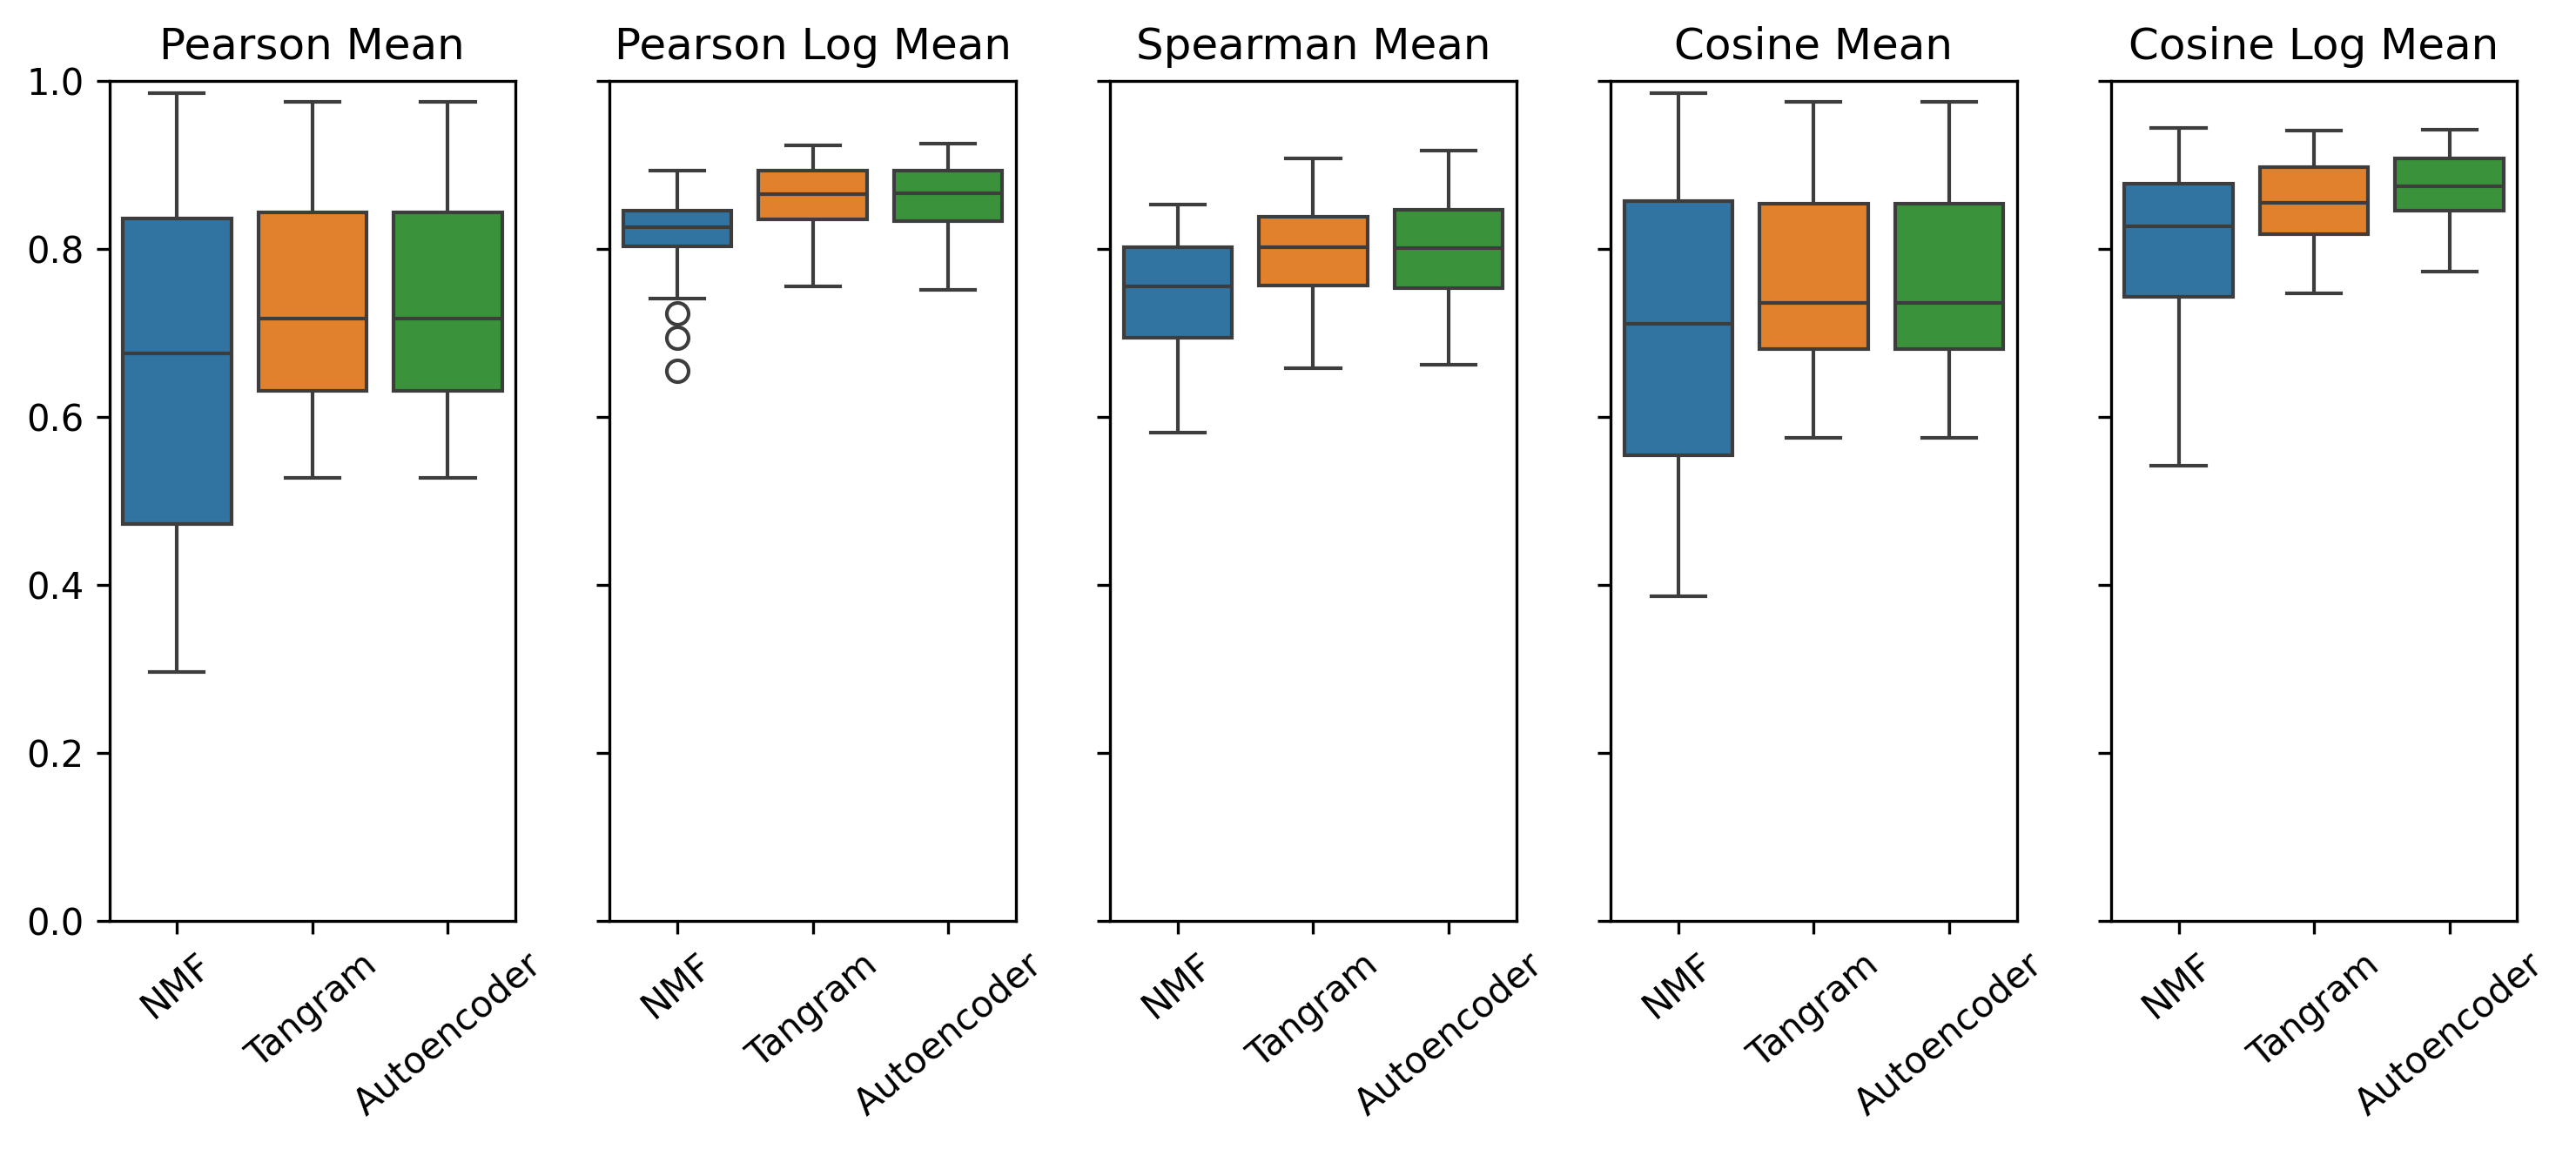

In [29]:
print(celltype)
fig, axes = plt.subplots(1, len(correlation_functions), figsize=(2/3 * len(results) * len(correlation_functions), 4.5), dpi=300, sharey=True)

for ax, (name, func) in zip(axes, correlation_functions.items()):
    data = {method: [reconstruction_result.compute_correlation(func) for reconstruction_result in result] for method, result in results.items()}
    sns.boxplot(data=data, ax=ax)
    ax.set_title(name)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40)

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

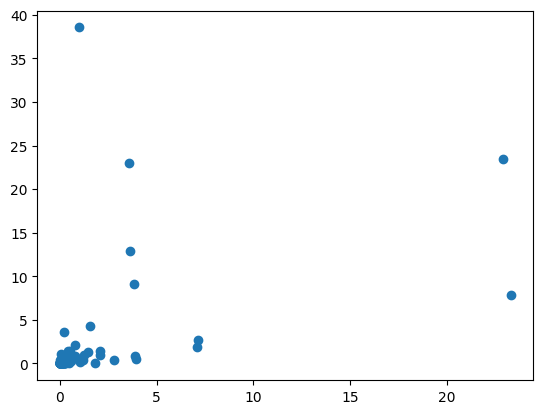

In [14]:
plt.scatter(
    Reconstruction_Result.from_reconstruction_result_collection(nmf_result).original_counts.values.mean(axis=0),
    Reconstruction_Result.from_reconstruction_result_collection(nmf_result).predicted_counts.values.mean(axis=0)
)   

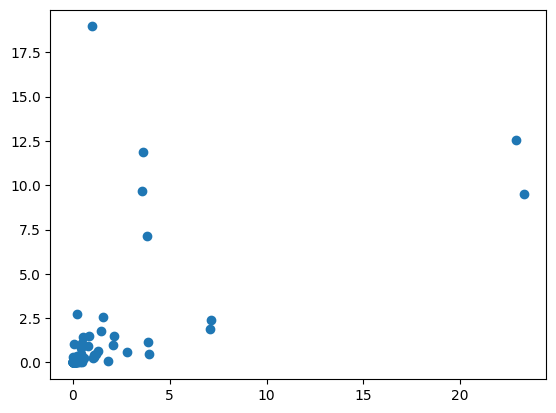

In [340]:
plt.scatter(
    Reconstruction_Result.from_reconstruction_result_collection(nmf_result).original_counts.values.mean(axis=0),
    Reconstruction_Result.from_reconstruction_result_collection(nmf_result).predicted_counts.values.mean(axis=0)
)   

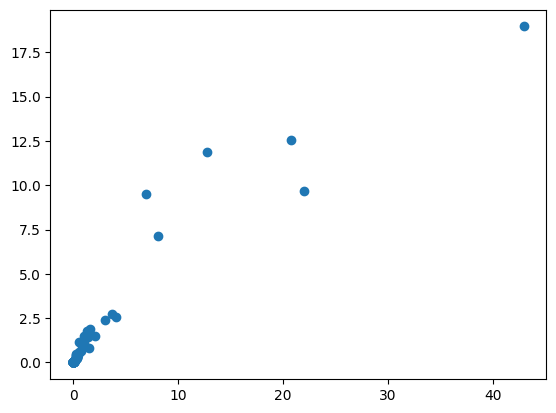

In [341]:
plt.scatter(
    Reconstruction_Result.from_reconstruction_result_collection(nmf_result).predicted_counts.values.mean(axis=0),
    Reconstruction_Result.from_reconstruction_result_collection(tangram_result).predicted_counts.values.mean(axis=0)
)  

In [330]:

genes = reduce(lambda x, y: set.union(x, y), [set(reconstruction_result.predicted_counts.columns) for reconstruction_result in nmf_result])

{'Acsl1',
 'Acta2',
 'Ada',
 'Adgrd1',
 'Adgrf5',
 'Adra2a',
 'Adrb1',
 'Adrb2',
 'Agr3',
 'Apob',
 'Avil',
 'C1qb',
 'C1qc',
 'Cadm1',
 'Ccl9',
 'Ccnl2',
 'Cd14',
 'Cd27',
 'Cd34',
 'Cd3d',
 'Cd4',
 'Cd44',
 'Cd79a',
 'Cd79b',
 'Chrm1',
 'Chrm3',
 'Clca3b',
 'Clec4a2',
 'Cmc1',
 'Cps1',
 'Crp',
 'Cysltr1',
 'Elavl3',
 'Etv1',
 'Fcgr4',
 'Fcna',
 'Ffar1',
 'Ffar2',
 'Ffar3',
 'Ffar4',
 'Fzd1',
 'Fzd10',
 'Fzd2',
 'Fzd3',
 'Fzd4',
 'Fzd5',
 'Fzd6',
 'Fzd7',
 'Fzd8',
 'Fzd9',
 'Galr1',
 'Galr3',
 'Gipr',
 'Gper1',
 'Gpr119',
 'Gpr18',
 'Gpr34',
 'Gpr55',
 'H2-Eb1',
 'Hmgb2',
 'Hrh1',
 'Htr1b',
 'Htr2b',
 'Htr4',
 'Icos',
 'Ifnar1',
 'Ighd',
 'Il3ra',
 'Isl1',
 'Itgae',
 'Itgam',
 'Jaml',
 'Kiss1r',
 'Kit',
 'Klk1',
 'Krt7',
 'Lamp3',
 'Lct',
 'Lgr5',
 'Lpar1',
 'Lpar2',
 'Lpar5',
 'Lpar6',
 'Lrmp',
 'Ltb4r1',
 'Ltb4r2',
 'Maged2',
 'Maoa',
 'Marcksl1',
 'Mboat4',
 'Mki67',
 'Mptx2',
 'Ms4a1',
 'Mzb1',
 'Neat1',
 'Nes',
 'Net1',
 'Neurog3',
 'Nlrp6',
 'Nt5e',
 'P2ry10',
 'Pax6',
 'Plb1',


In [282]:
predicted_counts = pd.DataFrame()
original_counts = pd.DataFrame()
for gene in shared_genes:
    predicted_counts[gene] = np.array([reconstruction_result.predicted_counts[gene].values for reconstruction_result in tangram_result if gene in reconstruction_result.predicted_counts.columns]).mean(axis=0)
    original_counts[gene] = np.array([reconstruction_result.original_counts[gene].values for reconstruction_result in tangram_result if gene in reconstruction_result.original_counts.columns]).mean(axis=0)

In [281]:
predicted_counts_nmf = predicted_counts.copy()

In [283]:

predicted_counts_tangram = predicted_counts.copy()

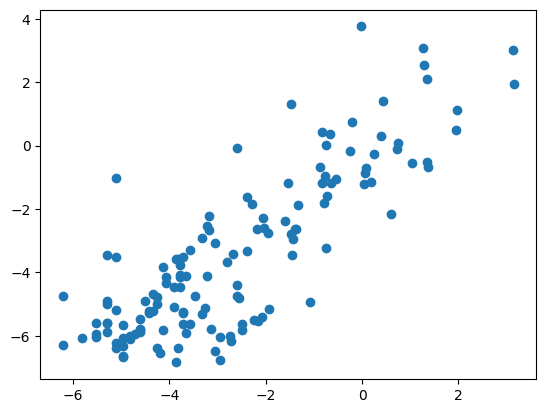

In [293]:
plt.scatter(
    np.log(adata_sp[:, shared_genes].X.mean(axis=0) + 1e-3),
    np.log(predicted_counts_nmf.values.mean(axis=0) + 1e-3)
)

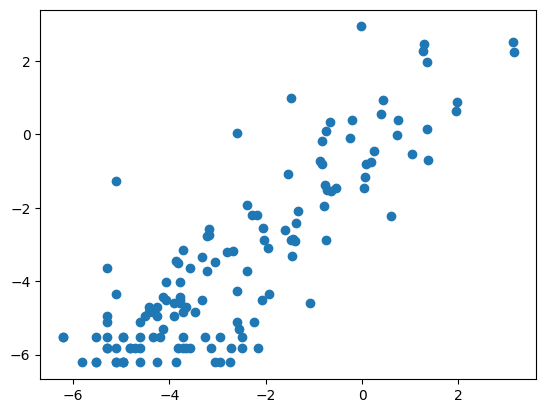

In [294]:
plt.scatter(
    np.log(adata_sp[:, shared_genes].X.mean(axis=0) + 1e-3),
    np.log(predicted_counts_tangram.values.mean(axis=0) + 1e-3)
)

In [300]:
import pandas as pd
import numpy as np

# Example data
array1 = np.array([1, 2, 3, 4])
array2 = np.array([10, 20, 30, 40])

# Create a DataFrame
df = pd.DataFrame({'Value1': array1, 'Value2': array2})

# Convert to long format
df_long = df.melt(var_name="Variable", value_name="Value")

print(df_long)

  Variable  Value
0   Value1      1
1   Value1      2
2   Value1      3
3   Value1      4
4   Value2     10
5   Value2     20
6   Value2     30
7   Value2     40


In [301]:
df

,Value1,Value2
0,1,10
1,2,20
2,3,30
3,4,40


In [325]:
df = pd.DataFrame({"original counts": np.log(adata_sp[:, shared_genes].X.mean(axis=0) + 1e-3), "NMF": np.log(predicted_counts_nmf.mean(axis=0) + 1e-3), "Tangram": np.log(predicted_counts_tangram.mean(axis=0) + 1e-3)}).reset_index()

In [310]:
len(shared_genes) * 3

414

In [327]:
df

,index,original counts,NMF,Tangram
0,Cd34,-3.054667,-6.491192,-6.213105
1,Stmn1,1.292512,2.548734,2.476681
2,S1pr2,-2.076461,-5.402024,-4.507128
3,Slc18a1,-2.587303,-4.381306,-4.265908
4,Gper1,-3.321315,-2.898733,-3.349488
...,...,...,...,...
133,Sstr3,-4.602466,-5.817834,-5.519207
134,Mptx2,0.079036,-0.717834,-0.797735
135,Cmc1,-2.587303,-0.074226,0.027694
136,Fzd10,-2.745914,-6.013661,-6.213105


In [323]:
df

,index,original counts,NMF,Tangram
0,Cd34,0.046138,0.000517,0.001003
1,Stmn1,3.640923,12.789901,11.900702
2,S1pr2,0.124373,0.003507,0.010030
3,Slc18a1,0.074223,0.011509,0.013039
4,Gper1,0.035105,0.054093,0.034102
...,...,...,...,...
133,Sstr3,0.009027,0.001974,0.003009
134,Mptx2,1.081244,0.486808,0.449348
135,Cmc1,0.074223,0.927462,1.027081
136,Fzd10,0.063190,0.001445,0.001003


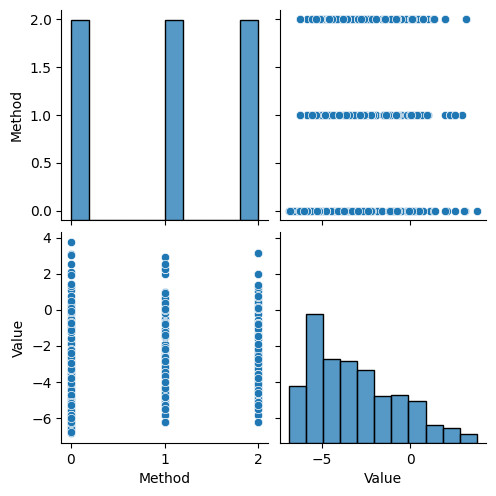

In [326]:
df_long = df.melt(id_vars="index", var_name="Method", value_name="Value")

# Convert categorical 'Method' column to numeric encoding (if needed)
df_long["Method"] = df_long["Method"].astype("category").cat.codes

# Pairplot on numeric columns only
sns.pairplot(df_long, vars=["Method", "Value"])

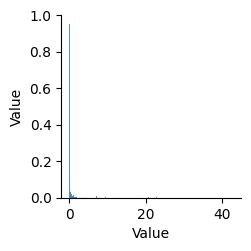

In [311]:
sns.pairplot(df.melt(var_name="Method", value_name="Value"))

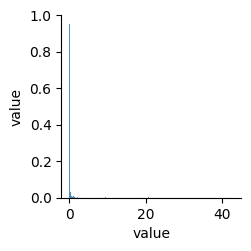

In [303]:
sns.pairplot(pd.DataFrame({"NMF": predicted_counts_nmf.mean(axis=0), "Tangram": predicted_counts_tangram.mean(axis=0)}).melt())

In [298]:
sns.pairplot([predicted_counts_nmf.mean(axis=0), predicted_counts_tangram.mean(axis=0)])

TypeError: 'data' must be pandas DataFrame object, not: <class 'list'>

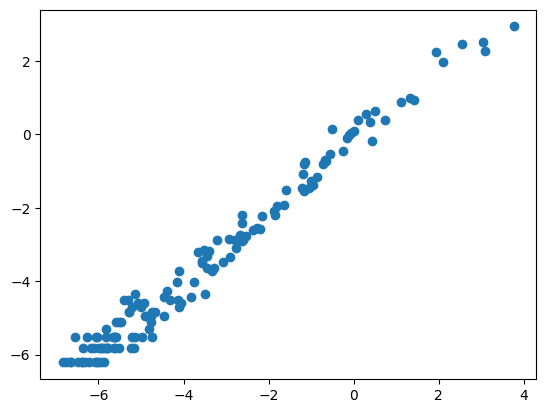

In [295]:
plt.scatter(
    np.log(predicted_counts_nmf.values.mean(axis=0) + 1e-3),
    np.log(predicted_counts_tangram.values.mean(axis=0) + 1e-3)
)

In [260]:
nmf_result[0].predicted_counts.columns

Index(['Vim', 'Kit', 'Neurog3', 'Adrb1', 'Cd79b', 'Gpr18', 'Txndc5', 'Htr2b',
       'Lct', 'Sox4', 'Taar4', 'Rgs4', 'Tbxa2r', 'Nes', 'Ptger4', 'Mboat4',
       'Cmc1', 'Stmn1', 'Ptger1', 'Ltb4r2', 'Galr1', 'Gpr34', 'Cd3d', 'Ptgdr2',
       'Ffar2', 'Ms4a1', 'Fzd10', 'S1pr3', 'Mki67', 'Net1', 'Thy1', 'Slc5a1',
       'Gpr119', 'Adgrf5', 'Ffar4', 'Sox10', 'Pax6', 'Sstr3', 'Avil', 'Ffar1'],
      dtype='object')

In [261]:
"Vim" in (nmf_result[0].predicted_counts.columns)

True

In [195]:
cosine_mean = transform_correlation_func(
    lambda x, y: float(cosine(x, y)),
    lambda x: x.mean(axis=0)
)

<Axes: >

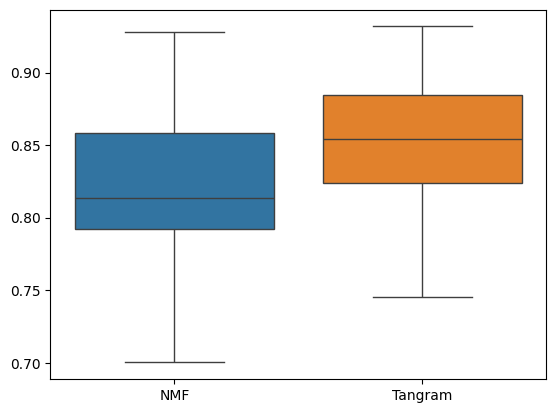

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


(0.0, 1.0)

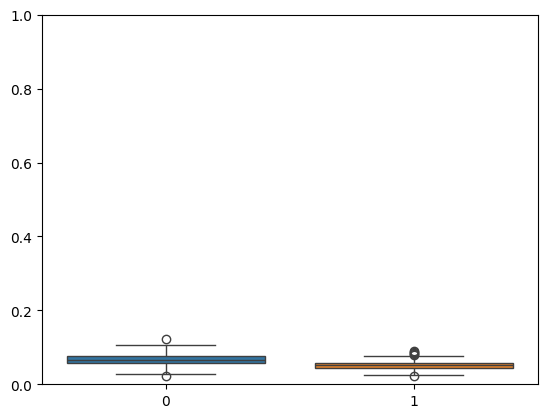

In [199]:
sns.boxplot(data = [[reconstruction_result.compute_correlation(cosine_log_mean) for reconstruction_result in result] for result in results.values()])
plt.ylim(0, 1)